# 01 - Exploratory Data Analysis dan Preprocessing

Notebook ini mendokumentasikan eksplorasi dataset gesture tangan kanan untuk project **Holographic Controller ML**. Dataset dikumpulkan dari webcam menggunakan MediaPipe Hands. Setiap baris berisi label gesture dan 63 fitur numerik dari 21 landmark tangan kanan.

## Tujuan EDA

1. Memeriksa ukuran dataset dan tipe data.
2. Memeriksa kualitas data: missing values, duplikat, dan konsistensi label.
3. Melihat distribusi kelas gesture.
4. Memahami pola awal fitur landmark.
5. Menyiapkan preprocessing untuk tahap modeling.

In [11]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_preprocessing import load_dataset, describe_dataset, prepare_features
from src.feature_extraction import feature_columns

DATA_PATH = ROOT / 'data/raw/gestures.csv'
data = load_dataset(DATA_PATH)
data.head()

,label,hand,x0,y0,z0,x1,y1,z1,x2,y2,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,right_cursor,Right,0.0,0.0,0.0,-0.266438,-0.237254,-0.129826,-0.424814,-0.593177,...,-0.184279,0.207915,-0.882087,-0.323782,0.134604,-0.642970,-0.286006,0.104527,-0.485851,-0.210158
1,right_cursor,Right,0.0,0.0,0.0,-0.269638,-0.244805,-0.117688,-0.431040,-0.597570,...,-0.177732,0.203815,-0.906515,-0.307589,0.130101,-0.662699,-0.258238,0.098346,-0.493105,-0.174405
2,right_cursor,Right,0.0,0.0,0.0,-0.279968,-0.243357,-0.124041,-0.433757,-0.601404,...,-0.164684,0.176496,-0.915765,-0.309891,0.106057,-0.669729,-0.276134,0.074940,-0.476896,-0.202017
3,right_cursor,Right,0.0,0.0,0.0,-0.271546,-0.229605,-0.117799,-0.449056,-0.594181,...,-0.158248,0.169170,-0.912056,-0.291849,0.101221,-0.670499,-0.257237,0.068629,-0.477089,-0.185492
4,right_cursor,Right,0.0,0.0,0.0,-0.274372,-0.252597,-0.106271,-0.432427,-0.634914,...,-0.156030,0.190985,-0.904835,-0.284153,0.115898,-0.671686,-0.246658,0.075893,-0.488514,-0.174036


## Statistik Deskriptif Awal

Dataset berisi label gesture, kolom `hand`, dan fitur landmark `x0, y0, z0` sampai `x20, y20, z20`.

In [12]:
print('Ukuran dataset:', data.shape)
print('Jumlah fitur landmark:', len(feature_columns()))
print('\nTipe data:')
print(data.dtypes.value_counts())
print('\nRingkasan kualitas data:')
describe_dataset(data)

Ukuran dataset: (999, 65)
Jumlah fitur landmark: 63

Tipe data:
float64    63
str         2
Name: count, dtype: int64

Ringkasan kualitas data:


{'rows': 999,
 'features': 63,
 'labels': {'right_click': 200,
  'right_arrow_left': 200,
  'right_arrow_right': 200,
  'idle': 200,
  'right_cursor': 199},
 'missing_values': {'label': 0,
  'hand': 0,
  'x0': 0,
  'y0': 0,
  'z0': 0,
  'x1': 0,
  'y1': 0,
  'z1': 0,
  'x2': 0,
  'y2': 0,
  'z2': 0,
  'x3': 0,
  'y3': 0,
  'z3': 0,
  'x4': 0,
  'y4': 0,
  'z4': 0,
  'x5': 0,
  'y5': 0,
  'z5': 0,
  'x6': 0,
  'y6': 0,
  'z6': 0,
  'x7': 0,
  'y7': 0,
  'z7': 0,
  'x8': 0,
  'y8': 0,
  'z8': 0,
  'x9': 0,
  'y9': 0,
  'z9': 0,
  'x10': 0,
  'y10': 0,
  'z10': 0,
  'x11': 0,
  'y11': 0,
  'z11': 0,
  'x12': 0,
  'y12': 0,
  'z12': 0,
  'x13': 0,
  'y13': 0,
  'z13': 0,
  'x14': 0,
  'y14': 0,
  'z14': 0,
  'x15': 0,
  'y15': 0,
  'z15': 0,
  'x16': 0,
  'y16': 0,
  'z16': 0,
  'x17': 0,
  'y17': 0,
  'z17': 0,
  'x18': 0,
  'y18': 0,
  'z18': 0,
  'x19': 0,
  'y19': 0,
  'z19': 0,
  'x20': 0,
  'y20': 0,
  'z20': 0},
 'duplicates': 0}

In [13]:
data['label'].value_counts().sort_index()

label
idle                 200
right_arrow_left     200
right_arrow_right    200
right_click          200
right_cursor         199
Name: count, dtype: int64

## Analisis Kualitas Data

Pemeriksaan dilakukan terhadap missing values dan duplikat. Dataset yang baik untuk klasifikasi gesture perlu bersih agar model tidak belajar dari data rusak atau berulang secara berlebihan.

In [14]:
missing_total = data.isna().sum().sum()
duplicate_total = data.duplicated().sum()
hand_counts = data['hand'].value_counts()

print('Total missing values:', missing_total)
print('Total duplikat:', duplicate_total)
print('\nDistribusi kolom hand:')
print(hand_counts)

Total missing values: 0
Total duplikat: 0

Distribusi kolom hand:
hand
Right    999
Name: count, dtype: int64


## Visualisasi Insight 1 - Distribusi Label

Distribusi label perlu seimbang agar model tidak bias ke salah satu gesture.

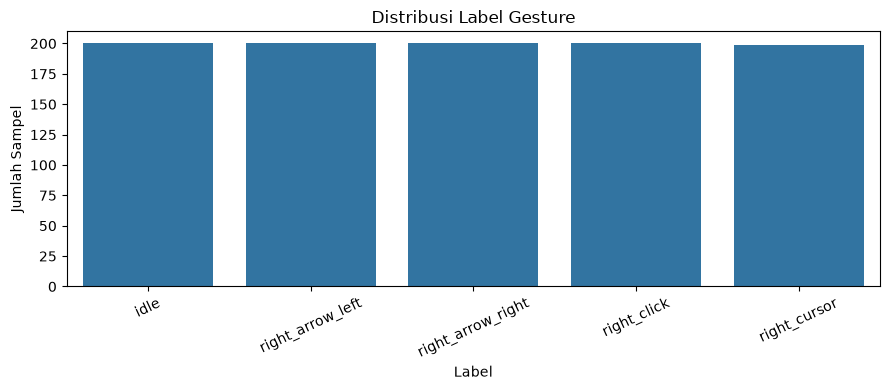

In [15]:
plt.figure(figsize=(9, 4))
sns.countplot(data=data, x='label', order=sorted(data['label'].unique()))
plt.title('Distribusi Label Gesture')
plt.xlabel('Label')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Visualisasi Insight 2 - Rata-Rata Posisi Ujung Jari Telunjuk

Landmark 8 adalah ujung jari telunjuk. Pada project ini landmark tersebut penting karena telunjuk kanan digunakan sebagai cursor/arah bidik.

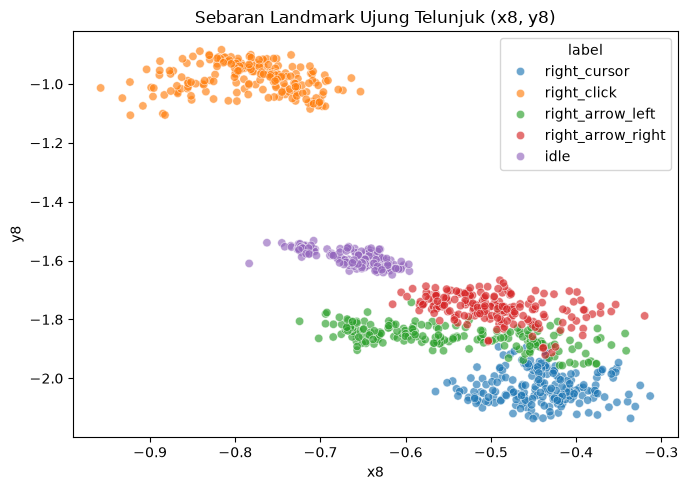

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='x8', y='y8', hue='label', alpha=0.65)
plt.title('Sebaran Landmark Ujung Telunjuk (x8, y8)')
plt.xlabel('x8')
plt.ylabel('y8')
plt.tight_layout()
plt.show()

## Visualisasi Insight 3 - Korelasi Fitur Utama

Korelasi fitur membantu melihat hubungan antar-landmark. Fitur yang sangat berkorelasi biasanya merepresentasikan pola bentuk tangan yang bergerak bersama.

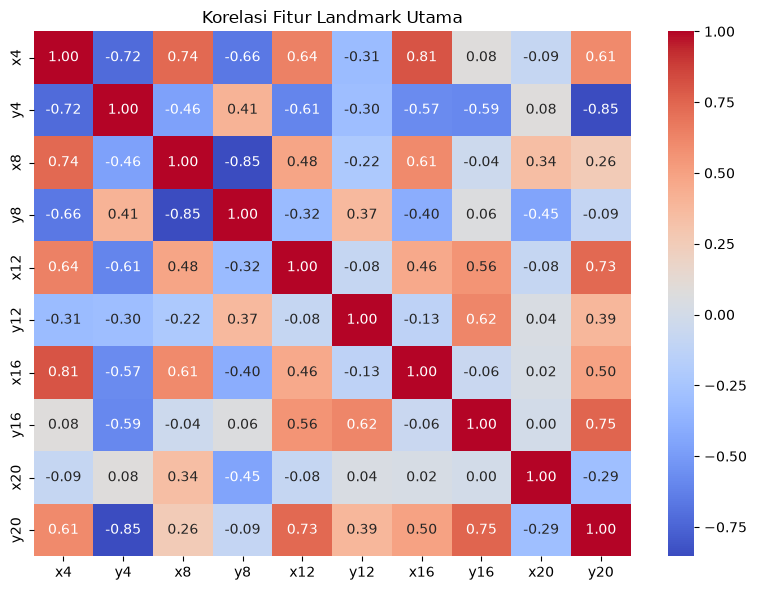

In [17]:
selected_features = ['x4', 'y4', 'x8', 'y8', 'x12', 'y12', 'x16', 'y16', 'x20', 'y20']
plt.figure(figsize=(8, 6))
sns.heatmap(data[selected_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Fitur Landmark Utama')
plt.tight_layout()
plt.show()

## Visualisasi Insight 4 - Perbedaan Bentuk Gesture

Boxplot fitur `y8` dapat membantu melihat variasi posisi telunjuk pada tiap gesture.

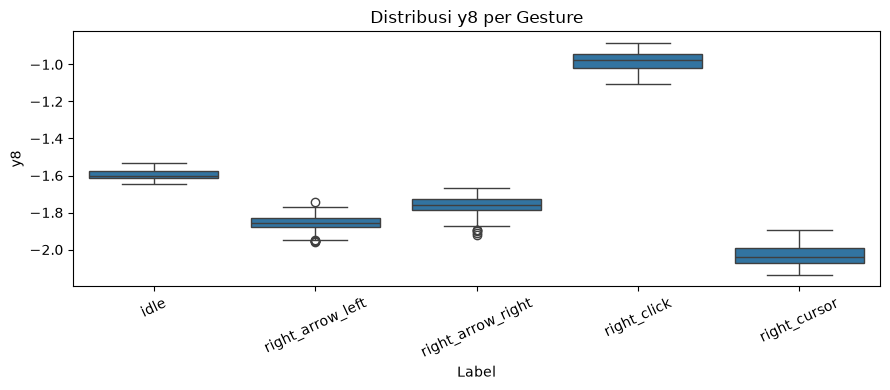

In [18]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=data, x='label', y='y8', order=sorted(data['label'].unique()))
plt.title('Distribusi y8 per Gesture')
plt.xlabel('Label')
plt.ylabel('y8')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Visualisasi Insight 5 - Ringkasan Fitur Numerik

Karena landmark sudah dinormalisasi terhadap pergelangan tangan, titik `x0`, `y0`, dan `z0` bernilai 0. Normalisasi ini membuat model lebih tahan terhadap perubahan posisi tangan di kamera.

In [19]:
data[feature_columns()].describe().loc[['mean', 'std', 'min', 'max']].round(3)

,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
mean,0.0,0.0,0.0,-0.248,-0.185,-0.082,-0.413,-0.493,-0.121,-0.440,...,-0.134,0.037,-0.958,-0.220,-0.000,-0.849,-0.213,-0.002,-0.777,-0.190
std,0.0,0.0,0.0,0.033,0.060,0.047,0.100,0.122,0.058,0.232,...,0.071,0.113,0.134,0.093,0.094,0.271,0.086,0.075,0.375,0.088
min,0.0,0.0,0.0,-0.349,-0.328,-0.272,-0.635,-0.706,-0.378,-0.831,...,-0.277,-0.271,-1.238,-0.432,-0.255,-1.447,-0.442,-0.223,-1.623,-0.476
max,0.0,0.0,0.0,-0.141,-0.014,0.067,-0.182,-0.216,0.077,-0.038,...,0.334,0.245,-0.673,0.336,0.184,-0.485,0.290,0.166,-0.324,0.256


## Preprocessing

Langkah preprocessing yang digunakan:

1. Menghapus duplikat.
2. Menghapus baris dengan missing values.
3. Mengambil 63 fitur landmark sebagai input.
4. Mengubah label gesture menjadi angka dengan `LabelEncoder`.
5. Melakukan scaling dengan `StandardScaler`.
6. Membagi data menjadi train, validation, dan test.

In [20]:
x_train, x_val, x_test, y_train, y_val, y_test, scaler, label_encoder = prepare_features(data)
print('Train:', x_train.shape)
print('Validation:', x_val.shape)
print('Test:', x_test.shape)
print('Label classes:', list(label_encoder.classes_))

Train: (599, 63)
Validation: (200, 63)
Test: (200, 63)
Label classes: ['idle', 'right_arrow_left', 'right_arrow_right', 'right_click', 'right_cursor']


## Kesimpulan EDA

- Dataset sudah memiliki 5 kelas gesture utama untuk controller game.
- Distribusi label relatif seimbang, sehingga cocok untuk klasifikasi multi-kelas.
- Tidak ditemukan missing values maupun duplikat pada dataset saat ini.
- Semua sampel berasal dari tangan kanan karena model difokuskan untuk gesture kanan.
- Fitur landmark sudah dinormalisasi, sehingga lebih stabil untuk training model.